# Build the MNIST Scaling Dataset

> We try make a dataset from a scaled network

In [ ]:
from ast import literal_eval

import matplotlib.pyplot as plt
import matrepr
import numpy as np
import torch
from matrepr import mprint
from natsort import natsorted
from safetensors.torch import load_model, save_file
from torchvision import datasets, transforms

from learningdynamics.models import MLP
from learningdynamics.utils import (
    compute_model_accuracy,
    getActivation,
    safetensors_metadata_parser,
)

In [ ]:
# | hide
matrepr.params.title = True
matrepr.params.indices = False
matrepr.params.precision = 4
matrepr.cell_align = "left"

%matplotlib inline

#### Load Dataset

In [ ]:
LAYER_START = 5

In [ ]:
# Build dataset
transform = transforms.Compose(
    [
        transforms.ToTensor(),  # first, convert image to PyTorch tensor
        transforms.Normalize((0.1307,), (0.3081,)),  # normalize inputs
    ]
)
train_set = datasets.MNIST(
    root="/mnt/datasets/", train=True, download=True, transform=transform
)
test_set = datasets.MNIST(
    root="/mnt/datasets/", train=False, download=True, transform=transform
)

In [ ]:
NUM_SAMPLES = len(train_set)
NUM_TRAJECTORIES = NUM_SAMPLES // 2  # Number of trajectories
MAGIC_NUMBER = -1

In [ ]:
## Override

# train_indices = torch.where(dataset.labels == 0)[0]
# test_indices = torch.where(dataset.labels == 1)[0]

# Randomly pick indices for training dataset
train_indices = np.random.choice(
    train_set.data.shape[0], size=NUM_TRAJECTORIES, replace=False
)

# Randomly pick indices for test dataset
test_indices = np.random.choice(
    np.setdiff1d(np.arange(NUM_SAMPLES), train_indices),
    size=int(NUM_SAMPLES - NUM_TRAJECTORIES),
    replace=False,
)

#### Load Original Model

In [ ]:
# Load model
file_path = "../saved_weights/mnist_model.safetensors"
metadata = safetensors_metadata_parser(file_path=file_path)
model = MLP(
    config=literal_eval(metadata["config"]),
    nonlinearity=metadata["nonlinearity"],
    in_features=784,
    out_features=10,
)
_ = load_model(model, file_path, device="cuda:0")

In [ ]:
_ = model.to("cpu")
print(f"Testing Accuracy: {compute_model_accuracy(model, test_set)}")

Testing Accuracy: 0.972000002861023


In [ ]:
model.eval()

MLP(
  (features): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=10, bias=True)
  )
)

#### Load Scaled Model

In [ ]:
# Load model
file_path = f"../saved_weights/mnist_start{LAYER_START}_scaled_model.safetensors"
metadata = safetensors_metadata_parser(file_path=file_path)
scaled_model = MLP(
    config=literal_eval(metadata["config"]),
    nonlinearity=metadata["nonlinearity"],
    in_features=784,
    out_features=10,
)
_ = load_model(scaled_model, file_path, device="cuda:0")

In [ ]:
_ = scaled_model.to("cpu")
print(f"Testing Accuracy: {compute_model_accuracy(scaled_model.to('cpu'), test_set)}")

Testing Accuracy: 0.9682999849319458


In [ ]:
scaled_model.eval()

MLP(
  (features): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=64, bias=True)
    (11): ReLU()
    (12): Linear(in_features=64, out_features=64, bias=True)
    (13): ReLU()
    (14): Linear(in_features=64, out_features=64, bias=True)
    (15): ReLU()
    (16): Linear(in_features=64, out_features=64, bias=True)
    (17): ReLU()
    (18): Linear(in_features=64, out_features=64, bias=True)
    (19): ReLU()
    (20): Linear(in_features=64, out_features=64, bias=True)
    (21): ReLU()
    (22): Linear(in_features=64, out_features=64, bias=True)
    (23): ReLU()
    (24): Linear(in_features=64, out_f

In [ ]:
LAYER_START = literal_eval(metadata["layer_start"])
NUM_STATES = literal_eval(metadata["layer_in_out"])
NUM_ITERATIONS = literal_eval(metadata["added_layers"]) + 2

LAYERS = [model.features[i] for i in (range(LAYER_START, LAYER_START + 3, 2))]
SCALED_LAYERS = [
    scaled_model.features[i]
    for i in (range(LAYER_START, LAYER_START + (NUM_ITERATIONS) * 2, 2))
]

#### Get activations

In [ ]:
hooks = []

# Dictionary to store activations
activation_dict = {}
scaled_activation_dict = {}

# Register the hooks
for idx, layer in enumerate(LAYERS):
    hooks.append(
        layer.register_forward_hook(getActivation(f"layer_{idx}", activation_dict))
    )

for idx, scaled_layer in enumerate(SCALED_LAYERS):
    hooks.append(
        scaled_layer.register_forward_hook(
            getActivation(f"scaled_layer_{idx}", scaled_activation_dict)
        )
    )

_ = model(train_set.data.float())
_ = scaled_model(train_set.data.float())

# Remove hook
for hook in hooks:
    hook.remove()

In [ ]:
def collect_timestep_tensor(dict, shuffle=False, magic_number=MAGIC_NUMBER):
    # sorted_dict = OrderedDict(natsorted(dict.items()))
    sorted_dict = dict
    values = list(sorted_dict.values())

    for i, v in enumerate(values):
        if v.shape[-1] != NUM_STATES:
            temp = torch.full((v.shape[0], NUM_STATES), magic_number)
            temp[:, : v.shape[-1]] = v
            values[i] = temp

    values_tensor = torch.stack(values)
    if shuffle:
        idx = torch.randperm(values_tensor.shape[1])
        values_tensor = values_tensor[:, idx, :]
    return values_tensor

#### Visualizing Trajectory

In [ ]:
SAMPLE = 0
PLOT_NUM_STATES = 5

In [ ]:
t = np.linspace(0, 1, 2)
states = collect_timestep_tensor(activation_dict, shuffle=False, magic_number=MAGIC_NUMBER)[:, SAMPLE, :].T

ts = np.linspace(0, 1, NUM_ITERATIONS)
scaled_states = collect_timestep_tensor(scaled_activation_dict, shuffle=False, magic_number=MAGIC_NUMBER)[:, SAMPLE, :].T

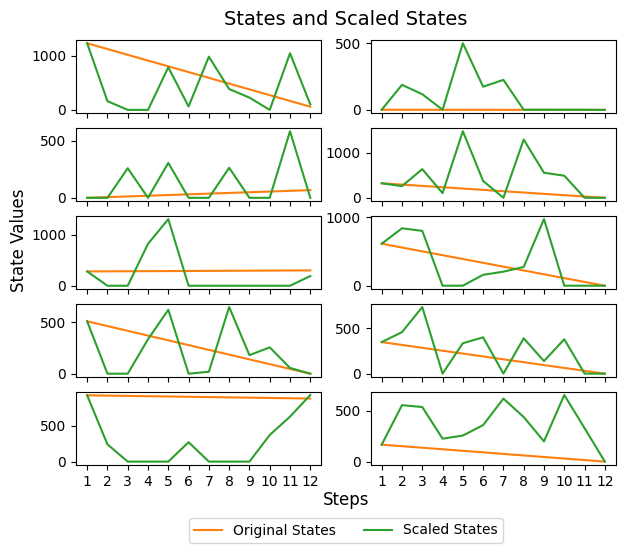

In [ ]:
fig, axs = plt.subplots(
    PLOT_NUM_STATES, 2, sharex=True, tight_layout=False, figsize=(6, 1 * PLOT_NUM_STATES)
)

# Plotting states
for state_idx in range(0, PLOT_NUM_STATES):
    axs[state_idx, 0].plot(t, states[state_idx, :], "-", color="tab:orange", label="Original States")
    axs[state_idx, 0].plot(ts, scaled_states[state_idx, :], "-", color="tab:green", label="Scaled States")
    axs[state_idx, 1].plot(t, states[-PLOT_NUM_STATES + state_idx, :], "-", color="tab:orange", label="Original States")
    axs[state_idx, 1].plot(ts, scaled_states[-PLOT_NUM_STATES + state_idx, :], "-", color="tab:green", label="Scaled States")

# Setting x-ticks and labels for the last subplot
axs[-1, 0].set_xticks(ts)
axs[-1, 0].set_xticklabels(range(1, NUM_ITERATIONS + 1))
axs[-1, 1].set_xticks(ts)
axs[-1, 1].set_xticklabels(range(1, NUM_ITERATIONS + 1))

# Adding legends outside the plots
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.12))

# Adding global titles and adjusting spacing
fig.suptitle('States and Scaled States', fontsize=14, y=0.96)
fig.text(0.5, -0.03, 'Steps', ha='center', fontsize=12)
fig.text(-0.06, 0.5, 'State Values', va='center', rotation='vertical', fontsize=12)

# Adjust layout to make space for the global titles and legends
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.9)
# plt.savefig('states.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [ ]:
metadata_dict = {
    "num_states": metadata["layer_in_out"],
    "num_trajectories": str(NUM_TRAJECTORIES),
    "num_iterations": str(NUM_ITERATIONS),
    "layer_start": metadata["layer_start"],
    "num_usable_states": str(scaled_model.features[LAYER_START + (NUM_ITERATIONS) * 2 - 3].out_features)
}

save_file(
    {
        "train_states": collect_timestep_tensor(scaled_activation_dict,magic_number=MAGIC_NUMBER)[
            :, train_indices, :
        ].contiguous(),
        "test_states": collect_timestep_tensor(scaled_activation_dict,magic_number=MAGIC_NUMBER)[
            :, test_indices, :
        ].contiguous(),
    },
    f"../saved_weights/mnist_start{LAYER_START}_states.safetensors",
    metadata=metadata_dict,
)